## Mounting Google Drive

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Important Libraries

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

## Path:

In [66]:
import os

base_path = "/content/drive/MyDrive/Deep-Learning/Study04/Room-classification"
data_path = os.path.join(base_path, "dataset")
visuals_path = os.path.join(base_path, "Visuals")

os.makedirs(visuals_path, exist_ok=True)

## Data Preprocessing

In [67]:
transform = transforms.Compose([
    transforms.Resize((64,64)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Flatten
])

## Loading Dataset

In [68]:
dataset = datasets.ImageFolder(root=data_path, transform=transform)

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_data, test_data = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

class_names = dataset.classes

print("Classes:", class_names)
print("Total images:", len(dataset))

Classes: ['bed_room', 'dining_room', 'living_room']
Total images: 393


## Visualize Sample Images

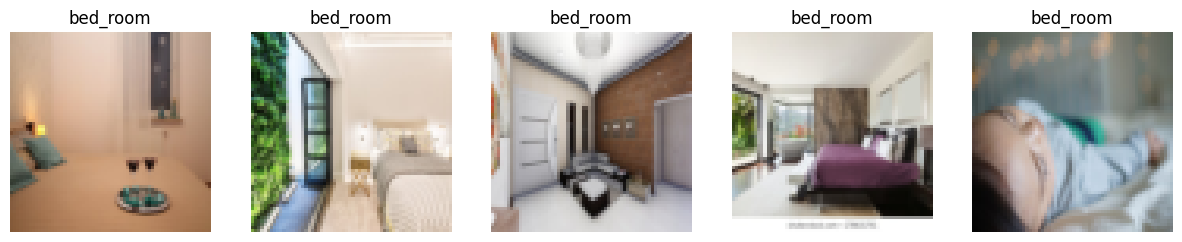

In [69]:
fig, axes = plt.subplots(1,5, figsize=(15,5))

for i in range(5):
    img, label = dataset[i]
    img = img.view(3,64,64)

    axes[i].imshow(img.permute(1,2,0))
    axes[i].set_title(class_names[label])
    axes[i].axis('off')

plt.savefig(visuals_path + "/sample_images.png")
plt.show()

## MLP Model:

In [70]:
input_size = 64 * 64 * 3
num_classes = len(class_names)

class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

model = MLP()

## Cross_EntropyLoss and ADAM optimizer

In [71]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Training

In [72]:
epochs = 50

train_losses = []
train_accuracies = []

for epoch in range(epochs):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.4f} | Accuracy: {accuracy:.2f}%")

Epoch [1/50] Loss: 2.1382 | Accuracy: 33.76%
Epoch [2/50] Loss: 1.1184 | Accuracy: 36.31%
Epoch [3/50] Loss: 1.2646 | Accuracy: 38.22%
Epoch [4/50] Loss: 1.0289 | Accuracy: 48.41%
Epoch [5/50] Loss: 1.0821 | Accuracy: 40.45%
Epoch [6/50] Loss: 1.0105 | Accuracy: 46.50%
Epoch [7/50] Loss: 0.9738 | Accuracy: 54.78%
Epoch [8/50] Loss: 1.0135 | Accuracy: 46.18%
Epoch [9/50] Loss: 0.9644 | Accuracy: 55.73%
Epoch [10/50] Loss: 0.9522 | Accuracy: 51.27%
Epoch [11/50] Loss: 0.9257 | Accuracy: 54.46%
Epoch [12/50] Loss: 0.9277 | Accuracy: 57.32%
Epoch [13/50] Loss: 0.9562 | Accuracy: 55.10%
Epoch [14/50] Loss: 0.8734 | Accuracy: 63.06%
Epoch [15/50] Loss: 0.8571 | Accuracy: 56.69%
Epoch [16/50] Loss: 0.8833 | Accuracy: 54.46%
Epoch [17/50] Loss: 0.8627 | Accuracy: 62.42%
Epoch [18/50] Loss: 0.8644 | Accuracy: 57.32%
Epoch [19/50] Loss: 0.8803 | Accuracy: 55.41%
Epoch [20/50] Loss: 0.8888 | Accuracy: 62.74%
Epoch [21/50] Loss: 0.7688 | Accuracy: 66.56%
Epoch [22/50] Loss: 0.8513 | Accuracy: 59.8

## VISUALIZATION SECTION

* Training Loss



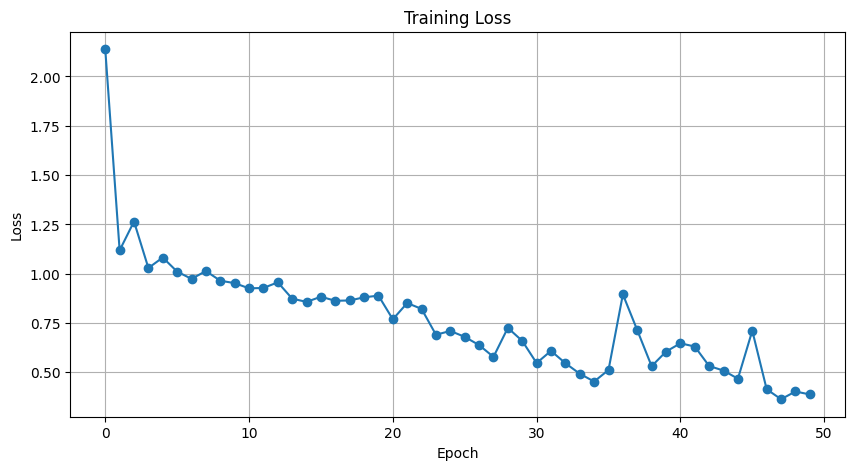

In [73]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.savefig(visuals_path + "/training_loss.png")
plt.show()

## Accuracy vs Epoch

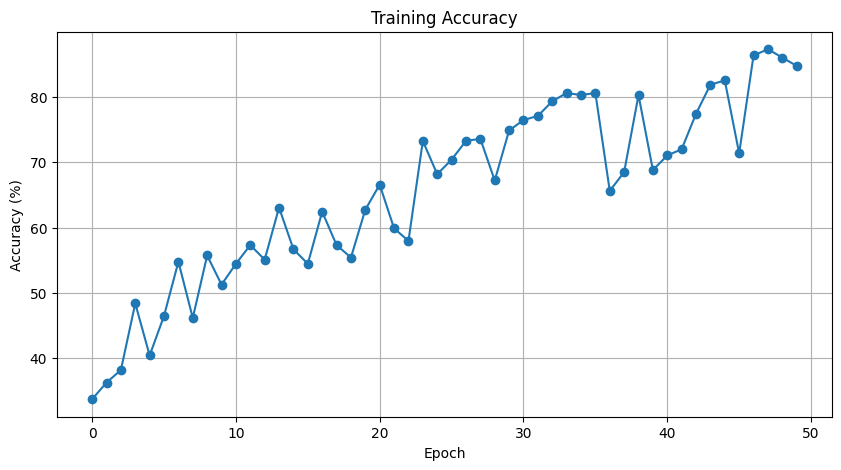

In [74]:
plt.figure(figsize=(10,5))
plt.plot(train_accuracies, marker='o')
plt.title("Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid()

plt.savefig(visuals_path + "/training_accuracy.png")
plt.show()

## Evaluation

In [75]:
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 41.77%


## Correct vs Incorrect

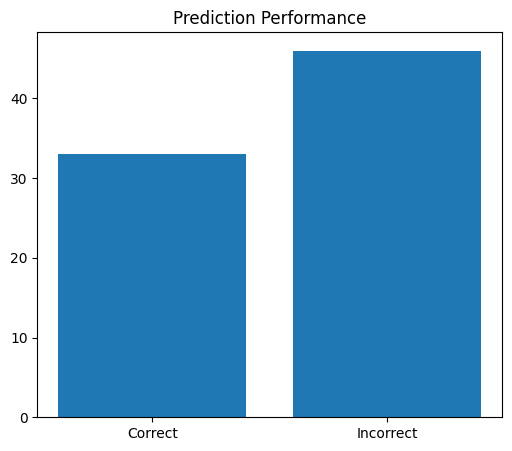

In [76]:
incorrect = total - correct

plt.figure(figsize=(6,5))
plt.bar(['Correct', 'Incorrect'], [correct, incorrect])
plt.title("Prediction Performance")

plt.savefig(visuals_path + "/correct_vs_incorrect.png")
plt.show()

## Class-wise Accuracy

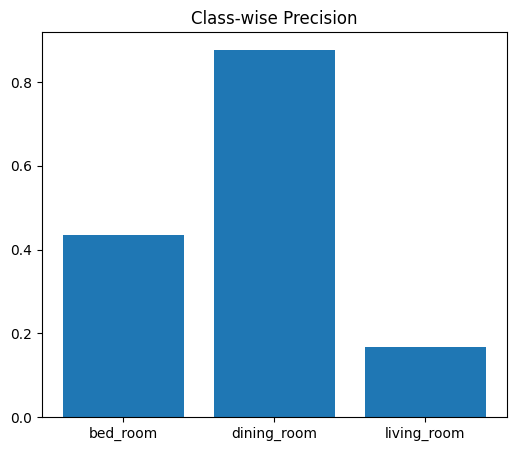

In [77]:
from sklearn.metrics import classification_report

report = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)

class_acc = [report[c]['precision'] for c in class_names]

plt.figure(figsize=(6,5))
plt.bar(class_names, class_acc)
plt.title("Class-wise Precision")

plt.savefig(visuals_path + "/class_accuracy.png")
plt.show()

## Prediction Grid

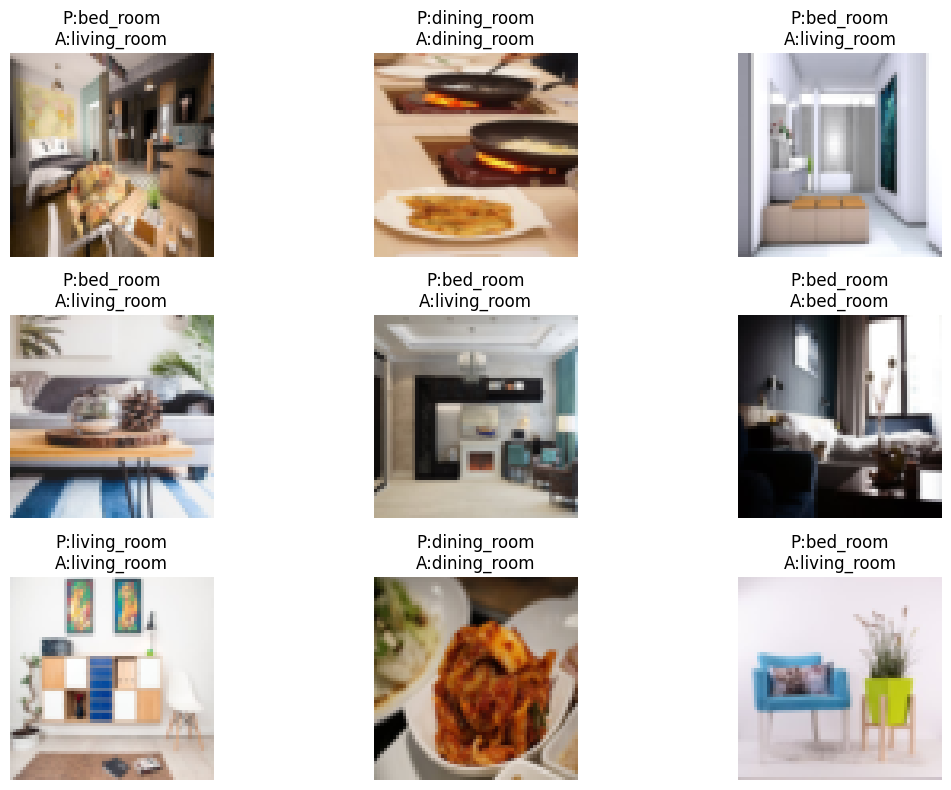

In [78]:
images, labels = next(iter(test_loader))
outputs = model(images)
_, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,8))

for i in range(9):
    img = images[i].view(3,64,64)

    plt.subplot(3,3,i+1)
    plt.imshow(img.permute(1,2,0))

    plt.title(f"P:{class_names[preds[i]]}\nA:{class_names[labels[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.savefig(visuals_path + "/prediction_grid.png")
plt.show()

## Single Prediction

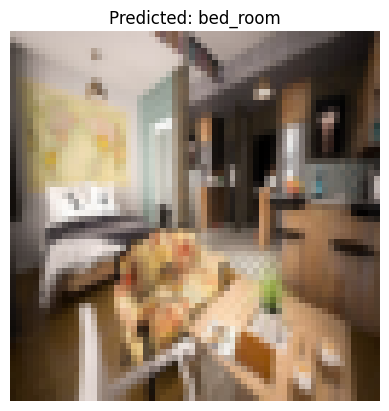

In [79]:
img = images[0].view(3,64,64)

plt.imshow(img.permute(1,2,0))
plt.title(f"Predicted: {class_names[preds[0]]}")
plt.axis('off')

plt.savefig(visuals_path + "/single_prediction.png")
plt.show()

##CONCLUSION

Purpose:
The purpose of this lab was to implement a Multi-Layer Perceptron (MLP)
for room image classification.

Results:
The model achieved low accuracy due to limitations of MLP.

Reason for Low Accuracy:
- MLP flattens images → loses spatial information
- Cannot detect patterns like edges and textures
- Not suitable for image classification tasks

Learning Outcome:
- Understood MLP working
- Learned preprocessing of images
- Analyzed model performance using graphs

Goal Achievement:
Yes, the implementation was successful and limitations were clearly observed.
